# Clean Evaluation of the Smoke Detection Model on the Full Video

This notebook keeps the outputs concise and organized.

Final outputs:

1. **Frame-level confusion matrix**
2. **Box-level / object-level confusion matrix**
3. **A one-row table containing parameters, main metrics, `mAP50`, and `mAP50-95`**
4. **A comparison video showing Ground Truth and model Predictions at the same time**
5. **A ZIP file containing these main outputs**

The model evaluates the full video. Frames included in `interpolated_all_frame_labels.csv` are treated as smoke frames, and all other frames are treated as background. Therefore, the frame-level confusion matrix has a real `TN` value.

In the box-level confusion matrix, evaluation is based on bounding boxes and IoU. In object detection, `TN` is not meaningfully defined, so only `TP / FP / FN` are meaningful and the `TN` cell is shown as `0`.


In [1]:

!pip install ultralytics -q

import os
import cv2
import json
import math
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import defaultdict
from IPython.display import display, Video
from ultralytics import YOLO

MODEL_PATH = "/kaggle/input/datasets/artinnader/yolo11n/coaf701ha.pt"
model = YOLO(MODEL_PATH)
model.model.names = {0: "fire", 1: "smoke"}

print("Model:", MODEL_PATH)
print("Model names:", model.model.names)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 92.1 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[

In [2]:

VIDEO_PATH = "/kaggle/input/datasets/artinnader/videos/smoke_p2.mp4"
GT_LABELS_CSV_PATH = "/kaggle/input/datasets/artinnader/labels-of-videos/interpolated_all_frame_labels_p2.csv"

if not Path(GT_LABELS_CSV_PATH).exists():
    fallback_csv = Path("/kaggle/working/video_smoke_interpolated_labels/interpolated_all_frame_labels.csv")
    if fallback_csv.exists():
        GT_LABELS_CSV_PATH = str(fallback_csv)

if not Path(GT_LABELS_CSV_PATH).exists():
    fallback_csv = Path("/mnt/data/interpolated_all_frame_labels.csv")
    if fallback_csv.exists():
        GT_LABELS_CSV_PATH = str(fallback_csv)

OUTPUT_ROOT = Path("/kaggle/working/smoke_clean_evaluation")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

FRAME_CONFUSION_MATRIX_PATH = OUTPUT_ROOT / "confusion_matrix_frame_level.png"
OBJECT_CONFUSION_MATRIX_PATH = OUTPUT_ROOT / "confusion_matrix_object_level.png"
SUMMARY_TABLE_CSV_PATH = OUTPUT_ROOT / "one_row_summary_metrics.csv"
COMPARISON_VIDEO_PATH = OUTPUT_ROOT / "gt_vs_model_comparison.mp4"
FINAL_ZIP_PATH = OUTPUT_ROOT / "clean_smoke_evaluation_outputs.zip"

FIRE_CLASS_ID = 0
SMOKE_CLASS_ID = 1
TRACK_CLASSES = [FIRE_CLASS_ID, SMOKE_CLASS_ID]
EVALUATE_ONLY_SMOKE = True

EVAL_FRAME_SIZE = (640, 640)

CONF_MIN = 0.20
CONF_STRONG = 0.55
CONF_ABSOLUTE = 0.88
NMS_IOU_THRESHOLD = 0.35

MIN_TRACK_AGE = 6
SMOKE_SCORE_THRESHOLD = 5.0
TRACK_HISTORY_LEN = 12

MAX_CENTER_SPEED_RATIO = 0.035
MIN_EXPANSION_RATIO = 0.08
MIN_SHAPE_CHANGE_RATIO = 0.06

MIN_BOX_AREA_RATIO = 0.0015
MAX_BOX_AREA_RATIO = 0.65

HUMAN_LIKE_ASPECT_MIN = 0.25
HUMAN_LIKE_ASPECT_MAX = 0.75

BBOX_SMOOTH_ALPHA = 0.65
BBOX_EXPAND_RATIO = 0.08
MAX_BBOX_EXPAND_RATIO = 0.18

IOU_MATCH_THRESHOLD = 0.50
EVAL_CONF_THRESHOLD = CONF_MIN
MAP_IOU_THRESHOLDS = np.round(np.arange(0.50, 0.96, 0.05), 2)

MAX_FRAMES_TO_PROCESS = None

print("VIDEO_PATH:", VIDEO_PATH)
print("GT_LABELS_CSV_PATH:", GT_LABELS_CSV_PATH)
print("OUTPUT_ROOT:", OUTPUT_ROOT)


VIDEO_PATH: /kaggle/input/datasets/artinnader/videos/smoke_p2.mp4
GT_LABELS_CSV_PATH: /kaggle/input/datasets/artinnader/labels-of-videos/interpolated_all_frame_labels_p2.csv
OUTPUT_ROOT: /kaggle/working/smoke_clean_evaluation


## 3) Helper Functions


In [3]:
def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Video could not be opened: {video_path}")
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    original_w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration_sec = total_frames / fps if fps > 0 else None
    cap.release()
    return {"fps": fps, "total_frames": total_frames, "original_w": original_w, "original_h": original_h, "duration_sec": duration_sec}


def create_video_writer(output_path, fps, size):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    for codec in ["mp4v", "avc1", "XVID"]:
        writer = cv2.VideoWriter(str(output_path), cv2.VideoWriter_fourcc(*codec), fps, size)
        if writer.isOpened():
            print(f"VideoWriter codec: {codec}")
            return writer
    raise RuntimeError("VideoWriter could not be opened.")


def safe_div(num, den):
    return float(num) / float(den) if den else 0.0


def clip_xyxy(x1, y1, x2, y2, w, h):
    x1 = max(0.0, min(float(x1), w - 1.0))
    y1 = max(0.0, min(float(y1), h - 1.0))
    x2 = max(0.0, min(float(x2), w - 1.0))
    y2 = max(0.0, min(float(y2), h - 1.0))
    if x2 < x1:
        x1, x2 = x2, x1
    if y2 < y1:
        y1, y2 = y2, y1
    return x1, y1, x2, y2


def calculate_iou_xyxy(box_a, box_b):
    ax1, ay1, ax2, ay2 = map(float, box_a)
    bx1, by1, bx2, by2 = map(float, box_b)
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def bbox_to_features(x1, y1, x2, y2, frame_w, frame_h):
    w = max(1.0, float(x2 - x1))
    h = max(1.0, float(y2 - y1))
    area = w * h
    return {
        "w": w,
        "h": h,
        "area": area,
        "cx": float(x1 + w / 2),
        "cy": float(y1 + h / 2),
        "aspect": w / h,
        "area_ratio": area / float(frame_w * frame_h),
        "diag": math.sqrt(frame_w ** 2 + frame_h ** 2)
    }


def expand_bbox_xyxy(x1, y1, x2, y2, expand_ratio, frame_w, frame_h):
    w, h = float(x2 - x1), float(y2 - y1)
    cx, cy = float(x1 + w / 2), float(y1 + h / 2)
    new_w, new_h = w * (1.0 + expand_ratio), h * (1.0 + expand_ratio)
    return clip_xyxy(cx - new_w / 2, cy - new_h / 2, cx + new_w / 2, cy + new_h / 2, frame_w, frame_h)


def smooth_bbox(track_id, box, track_smoothed_boxes):
    box = np.array(box, dtype=float)
    if track_id not in track_smoothed_boxes:
        track_smoothed_boxes[track_id] = box
        return box.tolist()
    previous = np.array(track_smoothed_boxes[track_id], dtype=float)
    smoothed = BBOX_SMOOTH_ALPHA * box + (1.0 - BBOX_SMOOTH_ALPHA) * previous
    track_smoothed_boxes[track_id] = smoothed
    return smoothed.tolist()


def analyze_track_motion(track_id, track_feature_history):
    history = track_feature_history[track_id]
    if len(history) < 2:
        return {"center_speed_ratio": 0.0, "expansion_ratio": 0.0, "shape_change_ratio": 0.0, "area_stable": True, "person_like_motion": False}
    first, last = history[0], history[-1]
    center_displacement = math.sqrt((last["cx"] - first["cx"]) ** 2 + (last["cy"] - first["cy"]) ** 2)
    center_speed_ratio = center_displacement / (last["diag"] + 1e-6)
    expansion_ratio = (last["area"] - first["area"]) / (first["area"] + 1e-6)
    aspect_change = abs(last["aspect"] - first["aspect"]) / (first["aspect"] + 1e-6)
    area_change_abs = abs(last["area"] - first["area"]) / (first["area"] + 1e-6)
    shape_change_ratio = max(aspect_change, area_change_abs)
    areas = np.array([h["area"] for h in history], dtype=float)
    area_stable = float(areas.std() / (areas.mean() + 1e-6)) < 0.10
    human_like_shape = HUMAN_LIKE_ASPECT_MIN <= last["aspect"] <= HUMAN_LIKE_ASPECT_MAX
    person_like_motion = human_like_shape and center_speed_ratio > MAX_CENTER_SPEED_RATIO and abs(expansion_ratio) < MIN_EXPANSION_RATIO and shape_change_ratio < MIN_SHAPE_CHANGE_RATIO * 2
    return {"center_speed_ratio": float(center_speed_ratio), "expansion_ratio": float(expansion_ratio), "shape_change_ratio": float(shape_change_ratio), "area_stable": bool(area_stable), "person_like_motion": bool(person_like_motion)}


def update_smoke_score(track_id, conf, features, motion_info, track_age, track_smoke_score):
    score = float(track_smoke_score[track_id]) * 0.88
    if conf >= CONF_ABSOLUTE:
        score += 4.0
    elif conf >= CONF_STRONG:
        score += 2.0
    elif conf >= CONF_MIN:
        score += 0.7
    score += 0.8 if track_age >= MIN_TRACK_AGE else -1.0
    if motion_info["expansion_ratio"] >= MIN_EXPANSION_RATIO:
        score += 1.3
    elif motion_info["shape_change_ratio"] >= MIN_SHAPE_CHANGE_RATIO:
        score += 0.8
    if motion_info["person_like_motion"]:
        score -= 4.0
    if motion_info["center_speed_ratio"] > MAX_CENTER_SPEED_RATIO and motion_info["area_stable"] and motion_info["expansion_ratio"] < MIN_EXPANSION_RATIO:
        score -= 2.5
    if features["area_ratio"] < MIN_BOX_AREA_RATIO:
        score -= 3.0
    if features["area_ratio"] > MAX_BOX_AREA_RATIO:
        score -= 2.0
    score = max(0.0, min(score, 20.0))
    track_smoke_score[track_id] = score
    confirmed = score >= SMOKE_SCORE_THRESHOLD and track_age >= MIN_TRACK_AGE
    if conf >= CONF_ABSOLUTE and not motion_info["person_like_motion"] and features["area_ratio"] >= MIN_BOX_AREA_RATIO:
        confirmed = True
    return confirmed, score


def empty_prediction_dataframe():
    return pd.DataFrame(columns=["frame_index_0_based", "timestamp_sec", "class_id", "class_name", "track_id", "confidence", "smoke_score", "track_age", "confirmed", "x1", "y1", "x2", "y2", "w", "h", "area", "area_ratio", "aspect"])


## 4) Reading Ground Truth and Preparing Dimensions


In [4]:
video_info = get_video_info(VIDEO_PATH)
fps = video_info["fps"]
total_frames = video_info["total_frames"]
original_w = video_info["original_w"]
original_h = video_info["original_h"]
output_w, output_h = EVAL_FRAME_SIZE

print("Video info:", video_info)

gt_df = pd.read_csv(GT_LABELS_CSV_PATH).copy()
required_cols = ["frame_index_0_based", "x1", "y1", "x2", "y2"]
missing_cols = [c for c in required_cols if c not in gt_df.columns]
if missing_cols:
    raise ValueError(f"Required columns are missing from the ground-truth CSV: {missing_cols}")

gt_df["frame_index_0_based"] = gt_df["frame_index_0_based"].astype(int)
gt_df = gt_df[(gt_df["frame_index_0_based"] >= 0) & (gt_df["frame_index_0_based"] < total_frames)].copy()

scale_x = output_w / original_w
scale_y = output_h / original_h

scaled_gt_df = gt_df.copy()
scaled_gt_df["gt_id"] = np.arange(len(scaled_gt_df))
scaled_gt_df["x1"] = scaled_gt_df["x1"] * scale_x
scaled_gt_df["x2"] = scaled_gt_df["x2"] * scale_x
scaled_gt_df["y1"] = scaled_gt_df["y1"] * scale_y
scaled_gt_df["y2"] = scaled_gt_df["y2"] * scale_y

clipped = scaled_gt_df.apply(lambda r: clip_xyxy(r["x1"], r["y1"], r["x2"], r["y2"], output_w, output_h), axis=1)
scaled_gt_df[["x1", "y1", "x2", "y2"]] = pd.DataFrame(clipped.tolist(), index=scaled_gt_df.index)
scaled_gt_df["timestamp_sec"] = scaled_gt_df["frame_index_0_based"] / fps

gt_positive_frames = set(scaled_gt_df["frame_index_0_based"].astype(int).tolist())

print(f"Total video frames: {total_frames}")
print(f"GT smoke frames: {len(gt_positive_frames)}")
print(f"GT background frames: {total_frames - len(gt_positive_frames)}")
display(scaled_gt_df.head())


Video info: {'fps': 29.906741843817613, 'total_frames': 942, 'original_w': 640, 'original_h': 640, 'duration_sec': 31.497914581247915}
Total video frames: 942
GT smoke frames: 748
GT background frames: 194


,frame_index_0_based,frame_number_1_based,timestamp_sec,x,y,w,h,x1,y1,x2,y2,is_keyframe,method,interp_from_frame,interp_to_frame,alpha,gt_id
0,0,1,0.000000,334.933000,192.0000,51.2,103.467000,334.933000,192.0000,386.133000,295.467000,True,keyframe,0,0,0.000000,0
1,1,2,0.033437,335.056077,191.2205,51.2,104.205462,335.056077,191.2205,386.256077,295.425962,False,linear_interpolation,0,26,0.038462,1
2,2,3,0.066875,335.179154,190.4410,51.2,104.943923,335.179154,190.4410,386.379154,295.384923,False,linear_interpolation,0,26,0.076923,2
3,3,4,0.100312,335.302231,189.6615,51.2,105.682385,335.302231,189.6615,386.502231,295.343885,False,linear_interpolation,0,26,0.115385,3
4,4,5,0.133749,335.425308,188.8820,51.2,106.420846,335.425308,188.8820,386.625308,295.302846,False,linear_interpolation,0,26,0.153846,4


## 5) Running the Model on the Full Video


In [5]:
process_start_frame = 0
process_end_frame = total_frames - 1
if MAX_FRAMES_TO_PROCESS is not None:
    process_end_frame = min(process_end_frame, process_start_frame + int(MAX_FRAMES_TO_PROCESS) - 1)

print(f"Processing frames: {process_start_frame} to {process_end_frame}")

track_feature_history = defaultdict(list)
track_smoke_score = defaultdict(float)
track_age_counter = defaultdict(int)
track_smoothed_boxes = {}
raw_prediction_rows = []
confirmed_prediction_rows = []

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Video could not be opened: {VIDEO_PATH}")
cap.set(cv2.CAP_PROP_POS_FRAMES, process_start_frame)

for frame_idx in range(process_start_frame, process_end_frame + 1):
    success, frame_original = cap.read()
    if not success or frame_original is None:
        print(f"Warning: failed to read frame {frame_idx}.")
        break

    frame = cv2.resize(frame_original, EVAL_FRAME_SIZE)
    results = model.track(frame, persist=True, conf=CONF_MIN, verbose=False, classes=TRACK_CLASSES)

    if len(results) == 0 or results[0].boxes is None or len(results[0].boxes) == 0:
        continue

    boxes = results[0].boxes.xyxy.cpu().numpy().astype(float)
    confidences = results[0].boxes.conf.cpu().numpy().astype(float)
    track_ids = results[0].boxes.id.cpu().numpy().astype(int) if results[0].boxes.id is not None else np.arange(len(boxes)).astype(int)
    class_ids = results[0].boxes.cls.cpu().numpy().astype(int) if results[0].boxes.cls is not None else np.full(len(boxes), SMOKE_CLASS_ID, dtype=int)

    nms_boxes = []
    for b in boxes:
        x1, y1, x2, y2 = b
        nms_boxes.append([float(x1), float(y1), float(x2 - x1), float(y2 - y1)])

    indices = cv2.dnn.NMSBoxes(nms_boxes, confidences.tolist(), score_threshold=CONF_MIN, nms_threshold=NMS_IOU_THRESHOLD)
    if len(indices) == 0:
        continue

    for i in np.array(indices).flatten():
        class_id = int(class_ids[i])
        if EVALUATE_ONLY_SMOKE and class_id != SMOKE_CLASS_ID:
            continue

        x1, y1, x2, y2 = clip_xyxy(*boxes[i], output_w, output_h)
        conf = float(confidences[i])
        track_id = int(track_ids[i])

        x1, y1, x2, y2 = smooth_bbox(track_id, [x1, y1, x2, y2], track_smoothed_boxes)
        x1, y1, x2, y2 = clip_xyxy(x1, y1, x2, y2, output_w, output_h)

        expand_ratio = BBOX_EXPAND_RATIO if conf >= CONF_STRONG else BBOX_EXPAND_RATIO * 0.5
        x1, y1, x2, y2 = expand_bbox_xyxy(x1, y1, x2, y2, min(expand_ratio, MAX_BBOX_EXPAND_RATIO), output_w, output_h)

        features = bbox_to_features(x1, y1, x2, y2, output_w, output_h)
        track_age_counter[track_id] += 1
        track_age = int(track_age_counter[track_id])
        track_feature_history[track_id].append(features)
        if len(track_feature_history[track_id]) > TRACK_HISTORY_LEN:
            track_feature_history[track_id].pop(0)

        motion_info = analyze_track_motion(track_id, track_feature_history)
        confirmed, smoke_score = update_smoke_score(track_id, conf, features, motion_info, track_age, track_smoke_score)

        row = {
            "frame_index_0_based": frame_idx,
            "timestamp_sec": frame_idx / fps,
            "class_id": class_id,
            "class_name": "smoke",
            "track_id": track_id,
            "confidence": conf,
            "smoke_score": float(smoke_score),
            "track_age": track_age,
            "confirmed": bool(confirmed),
            "x1": float(x1), "y1": float(y1), "x2": float(x2), "y2": float(y2),
            "w": float(x2 - x1), "h": float(y2 - y1),
            "area": float(features["area"]), "area_ratio": float(features["area_ratio"]), "aspect": float(features["aspect"])
        }
        raw_prediction_rows.append(row)
        if confirmed:
            confirmed_prediction_rows.append(row.copy())

cap.release()

raw_pred_df = pd.DataFrame(raw_prediction_rows) if raw_prediction_rows else empty_prediction_dataframe()
confirmed_pred_df = pd.DataFrame(confirmed_prediction_rows) if confirmed_prediction_rows else empty_prediction_dataframe()

print(f"Raw smoke predictions: {len(raw_pred_df)}")
print(f"Confirmed smoke predictions: {len(confirmed_pred_df)}")
display(confirmed_pred_df.head())


Processing frames: 0 to 941
requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 2 packages in 203ms
Prepared 1 package in 32ms
Installed 1 package in 5ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect

Raw smoke predictions: 816
Confirmed smoke predictions: 704


,frame_index_0_based,timestamp_sec,class_id,class_name,track_id,confidence,smoke_score,track_age,confirmed,x1,y1,x2,y2,w,h,area,area_ratio,aspect
0,5,0.167186,1,smoke,1,0.555418,7.563299,6,True,335.315560,176.384638,388.257398,323.540562,52.941838,147.155924,7790.705139,0.019020,0.359767
1,6,0.200624,1,smoke,1,0.293706,9.455703,7,True,335.987038,176.955290,388.598476,326.828969,52.611438,149.873679,7885.069794,0.019251,0.351039
2,7,0.234061,1,smoke,1,0.435658,11.121019,8,True,335.535867,175.244397,389.373772,330.797116,53.837905,155.552719,8374.632557,0.020446,0.346107
3,8,0.267498,1,smoke,1,0.443233,12.586497,9,True,335.189633,174.401084,389.474172,325.040060,54.284539,150.638976,8177.367366,0.019964,0.360362
4,9,0.300935,1,smoke,1,0.519992,13.876117,10,True,334.894656,173.814576,389.204971,318.104994,54.310315,144.290418,7836.458063,0.019132,0.376396


## 6) Computing Metrics and the One-Row Summary Table


In [6]:
def prepare_predictions_for_eval(pred_df, conf_threshold=0.10):
    if pred_df is None or pred_df.empty:
        return empty_prediction_dataframe()
    pred_eval = pred_df.copy()
    pred_eval = pred_eval[pred_eval["confidence"] >= conf_threshold].copy()
    pred_eval = pred_eval.sort_values("confidence", ascending=False).reset_index(drop=True)
    pred_eval["pred_id"] = np.arange(len(pred_eval))
    pred_eval["frame_index_0_based"] = pred_eval["frame_index_0_based"].astype(int)
    return pred_eval


def compute_frame_level_eval(gt_df, pred_df, total_frames, fps):
    pred_eval = prepare_predictions_for_eval(pred_df, conf_threshold=EVAL_CONF_THRESHOLD)
    gt_by_frame = {int(f): g.copy() for f, g in gt_df.groupby("frame_index_0_based")}
    pred_by_frame = {int(f): g.copy() for f, g in pred_eval.groupby("frame_index_0_based")}
    rows = []
    for frame_idx in range(total_frames):
        gt_group = gt_by_frame.get(frame_idx)
        pred_group = pred_by_frame.get(frame_idx)
        gt_present = gt_group is not None and len(gt_group) > 0
        pred_present = pred_group is not None and len(pred_group) > 0
        best_iou, best_conf = 0.0, np.nan
        if gt_present and pred_present:
            for _, gt in gt_group.iterrows():
                gt_box = [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
                for _, pred in pred_group.iterrows():
                    pred_box = [pred["x1"], pred["y1"], pred["x2"], pred["y2"]]
                    iou = calculate_iou_xyxy(gt_box, pred_box)
                    if iou > best_iou:
                        best_iou = iou
                        best_conf = float(pred["confidence"])
        elif pred_present:
            best_conf = float(pred_group["confidence"].max())

        if gt_present and pred_present:
            status = "TP"
        elif gt_present and not pred_present:
            status = "FN"
        elif (not gt_present) and pred_present:
            status = "FP"
        else:
            status = "TN"

        rows.append({
            "frame_index_0_based": frame_idx,
            "timestamp_sec": frame_idx / fps,
            "status": status,
            "best_iou": float(best_iou),
            "best_confidence": best_conf
        })
    return pd.DataFrame(rows)


def compute_ap_at_iou(pred_df, gt_df, iou_threshold=0.50):
    pred_eval = prepare_predictions_for_eval(pred_df, conf_threshold=EVAL_CONF_THRESHOLD)
    gt_eval = gt_df.copy().reset_index(drop=True)
    if "gt_id" not in gt_eval.columns:
        gt_eval["gt_id"] = np.arange(len(gt_eval))
    gt_by_frame = {int(f): g.copy() for f, g in gt_eval.groupby("frame_index_0_based")}
    matched_gt_ids = set()
    tp_list, fp_list = [], []

    for _, pred in pred_eval.iterrows():
        frame_idx = int(pred["frame_index_0_based"])
        pred_box = [pred["x1"], pred["y1"], pred["x2"], pred["y2"]]
        candidate_gt = gt_by_frame.get(frame_idx)
        best_iou, best_gt_id = 0.0, None
        if candidate_gt is not None and not candidate_gt.empty:
            for _, gt in candidate_gt.iterrows():
                gt_id = int(gt["gt_id"])
                if gt_id in matched_gt_ids:
                    continue
                gt_box = [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
                iou = calculate_iou_xyxy(pred_box, gt_box)
                if iou > best_iou:
                    best_iou, best_gt_id = iou, gt_id
        if best_gt_id is not None and best_iou >= iou_threshold:
            matched_gt_ids.add(best_gt_id)
            tp_list.append(1); fp_list.append(0)
        else:
            tp_list.append(0); fp_list.append(1)

    if len(tp_list) == 0:
        return 0.0
    cum_tp = np.cumsum(tp_list)
    cum_fp = np.cumsum(fp_list)
    recalls = cum_tp / max(len(gt_eval), 1)
    precisions = cum_tp / np.maximum(cum_tp + cum_fp, 1)
    mrec = np.concatenate(([0.0], recalls, [1.0]))
    mpre = np.concatenate(([0.0], precisions, [0.0]))
    for i in range(len(mpre) - 2, -1, -1):
        mpre[i] = max(mpre[i], mpre[i + 1])
    change_points = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[change_points + 1] - mrec[change_points]) * mpre[change_points + 1]))


def object_counts_at_iou(pred_df, gt_df, iou_threshold=0.50):
    pred_eval = prepare_predictions_for_eval(pred_df, conf_threshold=EVAL_CONF_THRESHOLD)
    gt_eval = gt_df.copy().reset_index(drop=True)
    if "gt_id" not in gt_eval.columns:
        gt_eval["gt_id"] = np.arange(len(gt_eval))
    gt_by_frame = {int(f): g.copy() for f, g in gt_eval.groupby("frame_index_0_based")}
    matched_gt_ids = set()
    TP_obj, FP_obj = 0, 0
    for _, pred in pred_eval.iterrows():
        frame_idx = int(pred["frame_index_0_based"])
        pred_box = [pred["x1"], pred["y1"], pred["x2"], pred["y2"]]
        candidate_gt = gt_by_frame.get(frame_idx)
        best_iou, best_gt_id = 0.0, None
        if candidate_gt is not None and not candidate_gt.empty:
            for _, gt in candidate_gt.iterrows():
                gt_id = int(gt["gt_id"])
                if gt_id in matched_gt_ids:
                    continue
                gt_box = [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
                iou = calculate_iou_xyxy(pred_box, gt_box)
                if iou > best_iou:
                    best_iou, best_gt_id = iou, gt_id
        if best_gt_id is not None and best_iou >= iou_threshold:
            matched_gt_ids.add(best_gt_id)
            TP_obj += 1
        else:
            FP_obj += 1
    FN_obj = int(len(gt_eval) - len(matched_gt_ids))
    return TP_obj, FP_obj, FN_obj


eval_pred_df = confirmed_pred_df.copy()
frame_eval_df = compute_frame_level_eval(scaled_gt_df, eval_pred_df, total_frames, fps)
counts = frame_eval_df["status"].value_counts().to_dict()
TP, FP, FN, TN = int(counts.get("TP", 0)), int(counts.get("FP", 0)), int(counts.get("FN", 0)), int(counts.get("TN", 0))

precision = safe_div(TP, TP + FP)
recall = safe_div(TP, TP + FN)
specificity = safe_div(TN, TN + FP)
accuracy = safe_div(TP + TN, TP + FP + FN + TN)
f1 = safe_div(2 * precision * recall, precision + recall)

TP_obj, FP_obj, FN_obj = object_counts_at_iou(eval_pred_df, scaled_gt_df, IOU_MATCH_THRESHOLD)
object_precision = safe_div(TP_obj, TP_obj + FP_obj)
object_recall = safe_div(TP_obj, TP_obj + FN_obj)
object_f1 = safe_div(2 * object_precision * object_recall, object_precision + object_recall)

mAP50 = compute_ap_at_iou(eval_pred_df, scaled_gt_df, 0.50)
mAP50_95 = float(np.mean([compute_ap_at_iou(eval_pred_df, scaled_gt_df, float(t)) for t in MAP_IOU_THRESHOLDS]))

summary_df = pd.DataFrame([{
    "CONF_MIN": CONF_MIN,
    "CONF_STRONG": CONF_STRONG,
    "CONF_ABSOLUTE": CONF_ABSOLUTE,
    "NMS_IOU_THRESHOLD": NMS_IOU_THRESHOLD,
    "IOU_MATCH_THRESHOLD": IOU_MATCH_THRESHOLD,
    "MIN_TRACK_AGE": MIN_TRACK_AGE,
    "SMOKE_SCORE_THRESHOLD": SMOKE_SCORE_THRESHOLD,
    "BBOX_EXPAND_RATIO": BBOX_EXPAND_RATIO,
    "Total_Frames": total_frames,
    "GT_Smoke_Frames": len(gt_positive_frames),
    "GT_Background_Frames": total_frames - len(gt_positive_frames),
    "TP": TP,
    "FP": FP,
    "FN": FN,
    "TN": TN,
    "Precision": precision,
    "Recall": recall,
    "Specificity": specificity,
    "Accuracy": accuracy,
    "F1": f1,
    "Object_TP": TP_obj,
    "Object_FP": FP_obj,
    "Object_FN": FN_obj,
    "Object_Precision": object_precision,
    "Object_Recall": object_recall,
    "Object_F1": object_f1,
    "mAP50": mAP50,
    "mAP50-95": mAP50_95
}])

summary_df.to_csv(SUMMARY_TABLE_CSV_PATH, index=False, encoding="utf-8-sig")
display(summary_df)
print("Saved:", SUMMARY_TABLE_CSV_PATH)


,CONF_MIN,CONF_STRONG,CONF_ABSOLUTE,NMS_IOU_THRESHOLD,IOU_MATCH_THRESHOLD,MIN_TRACK_AGE,SMOKE_SCORE_THRESHOLD,BBOX_EXPAND_RATIO,Total_Frames,GT_Smoke_Frames,...,Accuracy,F1,Object_TP,Object_FP,Object_FN,Object_Precision,Object_Recall,Object_F1,mAP50,mAP50-95
0,0.2,0.55,0.88,0.35,0.5,6,5.0,0.08,942,748,...,0.927813,0.952712,666,38,82,0.946023,0.890374,0.917355,0.877943,0.559573


Saved: /kaggle/working/smoke_clean_evaluation/one_row_summary_metrics.csv


## 7) Drawing and Saving the Two Confusion Matrices

This section creates two matrices:

1. **Frame-level confusion matrix**  
   The evaluation unit is the frame, and it has a real `TN` value.

2. **Object-level confusion matrix**  
   The evaluation unit is the bounding box and it is calculated based on IoU. In object detection, `TN` has no practical definition, so in the box-level matrix the `TN` cell is set to `0`, with focus on `TP / FP / FN`.


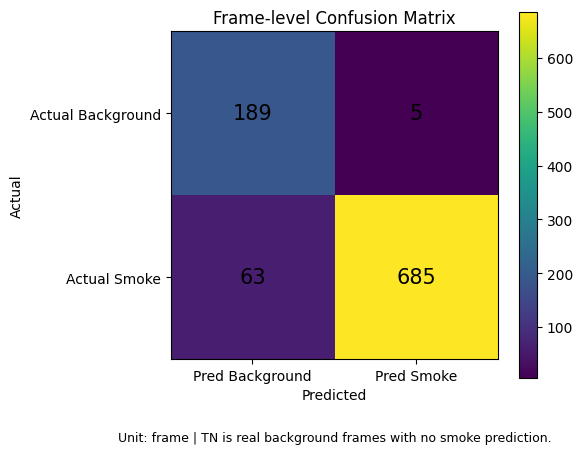

Saved: /kaggle/working/smoke_clean_evaluation/confusion_matrix_frame_level.png


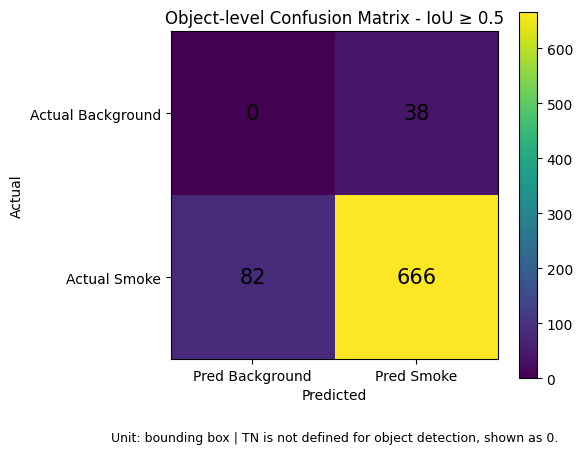

Saved: /kaggle/working/smoke_clean_evaluation/confusion_matrix_object_level.png


In [7]:
def plot_2x2_confusion_matrix(cm, title, output_path, note=None):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred Background", "Pred Smoke"])
    ax.set_yticklabels(["Actual Background", "Actual Smoke"])
    ax.set_title(title)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", fontsize=15)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    if note is not None:
        ax.text(
            0.5,
            -0.22,
            note,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=9
        )

    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


frame_cm = np.array([
    [TN, FP],
    [FN, TP]
], dtype=int)

plot_2x2_confusion_matrix(
    cm=frame_cm,
    title="Frame-level Confusion Matrix",
    output_path=FRAME_CONFUSION_MATRIX_PATH,
    note="Unit: frame | TN is real background frames with no smoke prediction."
)


if "OBJECT_TP" not in globals():
    OBJECT_TP = int(summary_df.loc[0, "Object_TP"])

if "OBJECT_FP" not in globals():
    OBJECT_FP = int(summary_df.loc[0, "Object_FP"])

if "OBJECT_FN" not in globals():
    OBJECT_FN = int(summary_df.loc[0, "Object_FN"])

OBJECT_TN = 0


object_cm = np.array([
    [OBJECT_TN, OBJECT_FP],
    [OBJECT_FN, OBJECT_TP]
], dtype=int)

plot_2x2_confusion_matrix(
    cm=object_cm,
    title=f"Object-level Confusion Matrix - IoU ≥ {IOU_MATCH_THRESHOLD}",
    output_path=OBJECT_CONFUSION_MATRIX_PATH,
    note="Unit: bounding box | TN is not defined for object detection, shown as 0."
)


## 8) Single GT vs Model Comparison Video


In [8]:
def draw_comparison_frame(frame, frame_idx, gt_group=None, pred_group=None, frame_status=None):
    status = "UNKNOWN"
    best_iou = 0.0
    if frame_status is not None:
        status = str(frame_status.get("status", "UNKNOWN"))
        best_iou = float(frame_status.get("best_iou", 0.0))

    if gt_group is not None and len(gt_group) > 0:
        for _, gt in gt_group.iterrows():
            x1, y1, x2, y2 = int(round(gt["x1"])), int(round(gt["y1"])), int(round(gt["x2"])), int(round(gt["y2"]))
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, "GT smoke", (x1, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0, 255, 0), 2)

    if pred_group is not None and len(pred_group) > 0:
        for _, pred in pred_group.iterrows():
            px1, py1, px2, py2 = int(round(pred["x1"])), int(round(pred["y1"])), int(round(pred["x2"])), int(round(pred["y2"]))
            pred_box = [pred["x1"], pred["y1"], pred["x2"], pred["y2"]]
            pred_best_iou = 0.0
            if gt_group is not None and len(gt_group) > 0:
                for _, gt in gt_group.iterrows():
                    gt_box = [gt["x1"], gt["y1"], gt["x2"], gt["y2"]]
                    pred_best_iou = max(pred_best_iou, calculate_iou_xyxy(pred_box, gt_box))
            color = (0, 165, 255) if pred_best_iou >= IOU_MATCH_THRESHOLD else (0, 0, 255)
            cv2.rectangle(frame, (px1, py1), (px2, py2), color, 2)
            cv2.putText(frame, f"Model {pred['confidence']:.2f}", (px1, min(output_h - 10, py2 + 20)), cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)

    header = f"frame={frame_idx} | t={frame_idx / fps:.2f}s | status={status} | IoU={best_iou:.3f}"
    cv2.rectangle(frame, (5, 5), (output_w - 5, 42), (0, 0, 0), -1)
    cv2.putText(frame, header, (12, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2)
    return frame


gt_by_frame = {int(f): g.copy() for f, g in scaled_gt_df.groupby("frame_index_0_based")}
pred_by_frame = {int(f): g.copy() for f, g in eval_pred_df.groupby("frame_index_0_based")}
frame_status_by_frame = {int(r["frame_index_0_based"]): r.to_dict() for _, r in frame_eval_df.iterrows()}

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise FileNotFoundError(f"Video could not be opened: {VIDEO_PATH}")
writer = create_video_writer(COMPARISON_VIDEO_PATH, fps, (output_w, output_h))

written = 0
for frame_idx in range(total_frames):
    success, frame_original = cap.read()
    if not success or frame_original is None:
        print(f"Warning: failed to read frame {frame_idx}.")
        break
    frame = cv2.resize(frame_original, EVAL_FRAME_SIZE)
    frame = draw_comparison_frame(frame, frame_idx, gt_by_frame.get(frame_idx), pred_by_frame.get(frame_idx), frame_status_by_frame.get(frame_idx))
    writer.write(frame)
    written += 1

cap.release()
writer.release()

print("Saved:", COMPARISON_VIDEO_PATH)
print(f"Written frames: {written}")
print(f"Duration: {written / fps:.3f} sec")
print(f"File size: {COMPARISON_VIDEO_PATH.stat().st_size / (1024 * 1024):.2f} MB")
display(Video(str(COMPARISON_VIDEO_PATH), embed=False, width=720))


VideoWriter codec: mp4v
Saved: /kaggle/working/smoke_clean_evaluation/gt_vs_model_comparison.mp4
Written frames: 774
Duration: 25.880 sec
File size: 24.72 MB


## 9) Final Minimal ZIP File


In [9]:
if FINAL_ZIP_PATH.exists():
    FINAL_ZIP_PATH.unlink()
with zipfile.ZipFile(FINAL_ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for p in [FRAME_CONFUSION_MATRIX_PATH,
        OBJECT_CONFUSION_MATRIX_PATH, SUMMARY_TABLE_CSV_PATH, COMPARISON_VIDEO_PATH]:
        p = Path(p)
        if p.exists():
            zf.write(p, arcname=p.name)
print("Final ZIP:", FINAL_ZIP_PATH)
print(f"ZIP size: {FINAL_ZIP_PATH.stat().st_size / (1024 * 1024):.2f} MB")


Final ZIP: /kaggle/working/smoke_clean_evaluation/clean_smoke_evaluation_outputs.zip
ZIP size: 24.53 MB
